# 🛡️ CkCk Hoax Detection AI — Training Notebook

**Track B: The Privacy Brain (NLP / Generative AI)**

Fine-tuning IndoBERT-base-p2 for Indonesian hoax detection with integrated PII filtering.

---

## 1. Setup & Imports

In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import yaml

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

from src.utils import set_seed, get_device, count_parameters, load_config
from src.dataset import create_dataloaders, load_data_from_csv
from src.preprocessing import TextPreprocessor
from src.pii_filter import PIIFilter
from src.trainer import Trainer

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

/Users/khomandan/Documents/Projects/CkCk-Hoax-Detection-AI/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


PyTorch version: 2.8.0
CUDA available: False


In [2]:
# Load configuration
config = load_config('config.yaml')
set_seed(config['training']['seed'])
device = get_device()

print(f"\nModel: {config['model']['name']}")
print(f"Epochs: {config['training']['epochs']}")
print(f"Batch size: {config['training']['batch_size']}")
print(f"Learning rate: {config['training']['learning_rate']}")

[INFO] Random seed set to 42
[INFO] Using Mac GPU (MPS)

Model: indobenchmark/indobert-base-p2
Epochs: 5
Batch size: 16
Learning rate: 2e-05


## 2. Data Exploration

In [3]:
# Load and explore training data
train_df = pd.read_csv(config['data']['train_path'])
print(f'Training samples: {len(train_df)}')
print(f'\nColumns: {list(train_df.columns)}')
print(f'\nLabel distribution:')
print(train_df['label'].value_counts())
print(f'\nSample entries:')
train_df.head()

Training samples: 23944

Columns: ['text', 'label']

Label distribution:
label
1    12744
0    11200
Name: count, dtype: int64

Sample entries:


,text,label
0,anggota komisi iv dpr ri rajiv meminta aparat ...,0
1,badan strategi kebijakan dalam negeri (bskdn) ...,0
2,sekretaris kabinet (seskab) teddy indra wijaya...,0
3,ekonom partai golkar abdul rahman farisi meman...,0
4,wakil menteri dalam negeri (wamendagri) bima a...,0


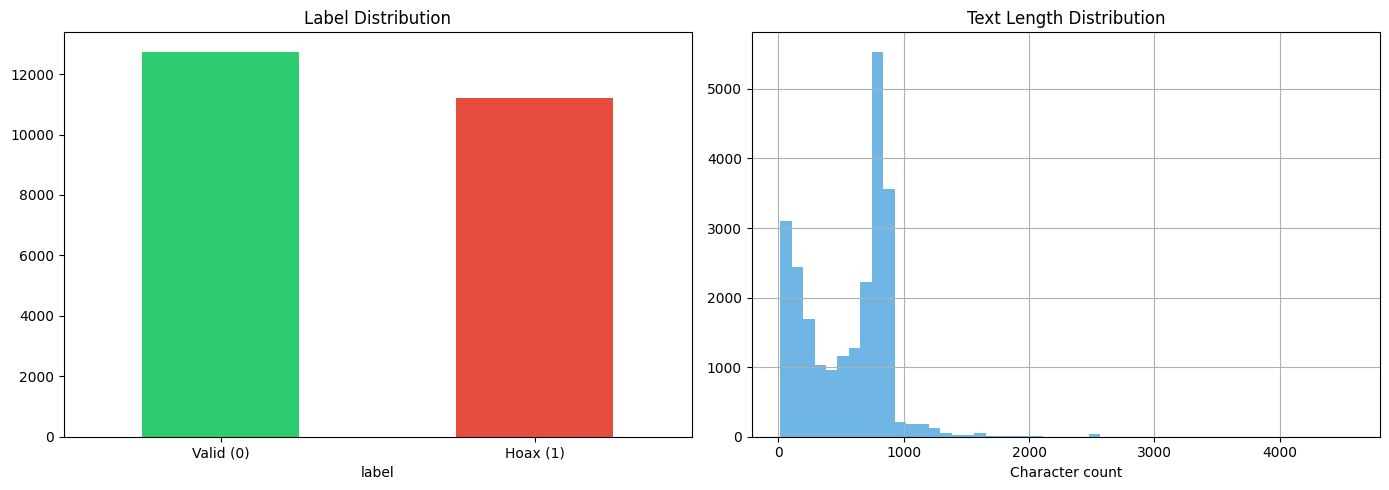

In [4]:
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
train_df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Label Distribution')
axes[0].set_xticklabels(['Valid (0)', 'Hoax (1)'], rotation=0)

# Text length distribution
train_df['text_length'].hist(bins=50, ax=axes[1], color='#3498db', alpha=0.7)
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Character count')

plt.tight_layout()
plt.show()

## 3. PII Filter Verification

In [5]:
# Test PII Filter
pii_filter = PIIFilter()

test_texts = [
    'NIK saya 3201234506780001 tolong dijaga.',
    'Hubungi di +6281234567890 atau email budi@gmail.com',
    'Transfer ke rekening 1234567890123456',
    'Berita ini tidak mengandung data pribadi.',
]

for text in test_texts:
    result = pii_filter.filter(text)
    print(f'Input:    {result["original_text"]}')
    print(f'Filtered: {result["filtered_text"]}')
    print(f'PII found: {result["pii_count"]}')
    print()

Input:    NIK saya 3201234506780001 tolong dijaga.
Filtered: NIK saya ████████████████ tolong dijaga.
PII found: 1

Input:    Hubungi di +6281234567890 atau email budi@gmail.com
Filtered: Hubungi di ██████████████ atau email ██████████████
PII found: 2

Input:    Transfer ke rekening 1234567890123456
Filtered: Transfer ke rekening ████████████████
PII found: 1

Input:    Berita ini tidak mengandung data pribadi.
Filtered: Berita ini tidak mengandung data pribadi.
PII found: 0



## 4. Preprocessing Test

In [6]:
# Test preprocessing pipeline
preprocessor = TextPreprocessor(use_stemmer=False)

samples = [
    'BREAKING!!! Vaksin COVID berbahaya!! https://hoax.com #antivax',
    '<p>Pemerintah <b>mengumumkan</b> kebijakan baru.</p>',
    'Gak percaya gw dgn berita ini!!!',
]

for text in samples:
    cleaned = preprocessor.clean(text, normalize_slang=True)
    print(f'Original: {text}')
    print(f'Cleaned:  {cleaned}')
    print()

Original: BREAKING!!! Vaksin COVID berbahaya!! https://hoax.com #antivax
Cleaned:  breaking! vaksin covid berbahaya!

Original: <p>Pemerintah <b>mengumumkan</b> kebijakan baru.</p>
Cleaned:  pemerintah mengumumkan kebijakan baru.

Original: Gak percaya gw dgn berita ini!!!
Cleaned:  tidak percaya gw dengan berita ini!



## 5. Model Setup & Parameter Count

In [7]:
# Load model and verify parameter count (Constraint B-1)
model = AutoModelForSequenceClassification.from_pretrained(
    config['model']['name'],
    num_labels=config['model']['num_labels'],
)

total_params = count_parameters(model)
print(f'\n✅ Constraint B-1: {total_params:,} params (limit: 4,000,000,000)')
print(f'   Using {total_params/4_000_000_000*100:.2f}% of allowed budget')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Total params: 124,442,882 | Trainable: 124,442,882

✅ Constraint B-1: 124,442,882 params (limit: 4,000,000,000)
   Using 3.11% of allowed budget


## 6. Training

In [9]:
# Initialize trainer and run training
trainer = Trainer.from_config('config.yaml')
trainer.setup()
history = trainer.train()

[INFO] Device: cpu
[INFO] Setting up training pipeline...


KeyboardInterrupt: 

## 7. Training Curves

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-o', label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['val_accuracy'], 'g-o')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

# F1 Score
axes[2].plot(epochs, history['val_f1'], 'm-o')
axes[2].set_title('Validation F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [ ]:
# Evaluate on test set
test_metrics = trainer.evaluate()

if test_metrics:
    print(f"\n📊 Final Test Metrics:")
    print(f"   Accuracy:  {test_metrics['accuracy']:.4f}")
    print(f"   F1 Score:  {test_metrics['f1']:.4f}")
    print(f"   Precision: {test_metrics['precision']:.4f}")
    print(f"   Recall:    {test_metrics['recall']:.4f}")

## 9. Save Final Model

In [ ]:
# Model is automatically saved during training (best checkpoint)
# Verify saved model exists
model_path = os.path.join(config['paths']['model_dir'], 'best_model')
if os.path.exists(model_path):
    files = os.listdir(model_path)
    print(f'✅ Model saved at: {model_path}')
    print(f'   Files: {files}')
else:
    print('⚠️  No saved model found. Training may not have completed.')

---

**Training complete!** Proceed to `inference.ipynb` for the clean inference pipeline.